In [135]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [136]:
!pip install opencv-python

In [137]:
# computer vision
import cv2
from google.colab.patches import cv2_imshow
from imutils.object_detection import non_max_suppression
from skimage.metrics import structural_similarity as ssim


import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from shapely.geometry import box

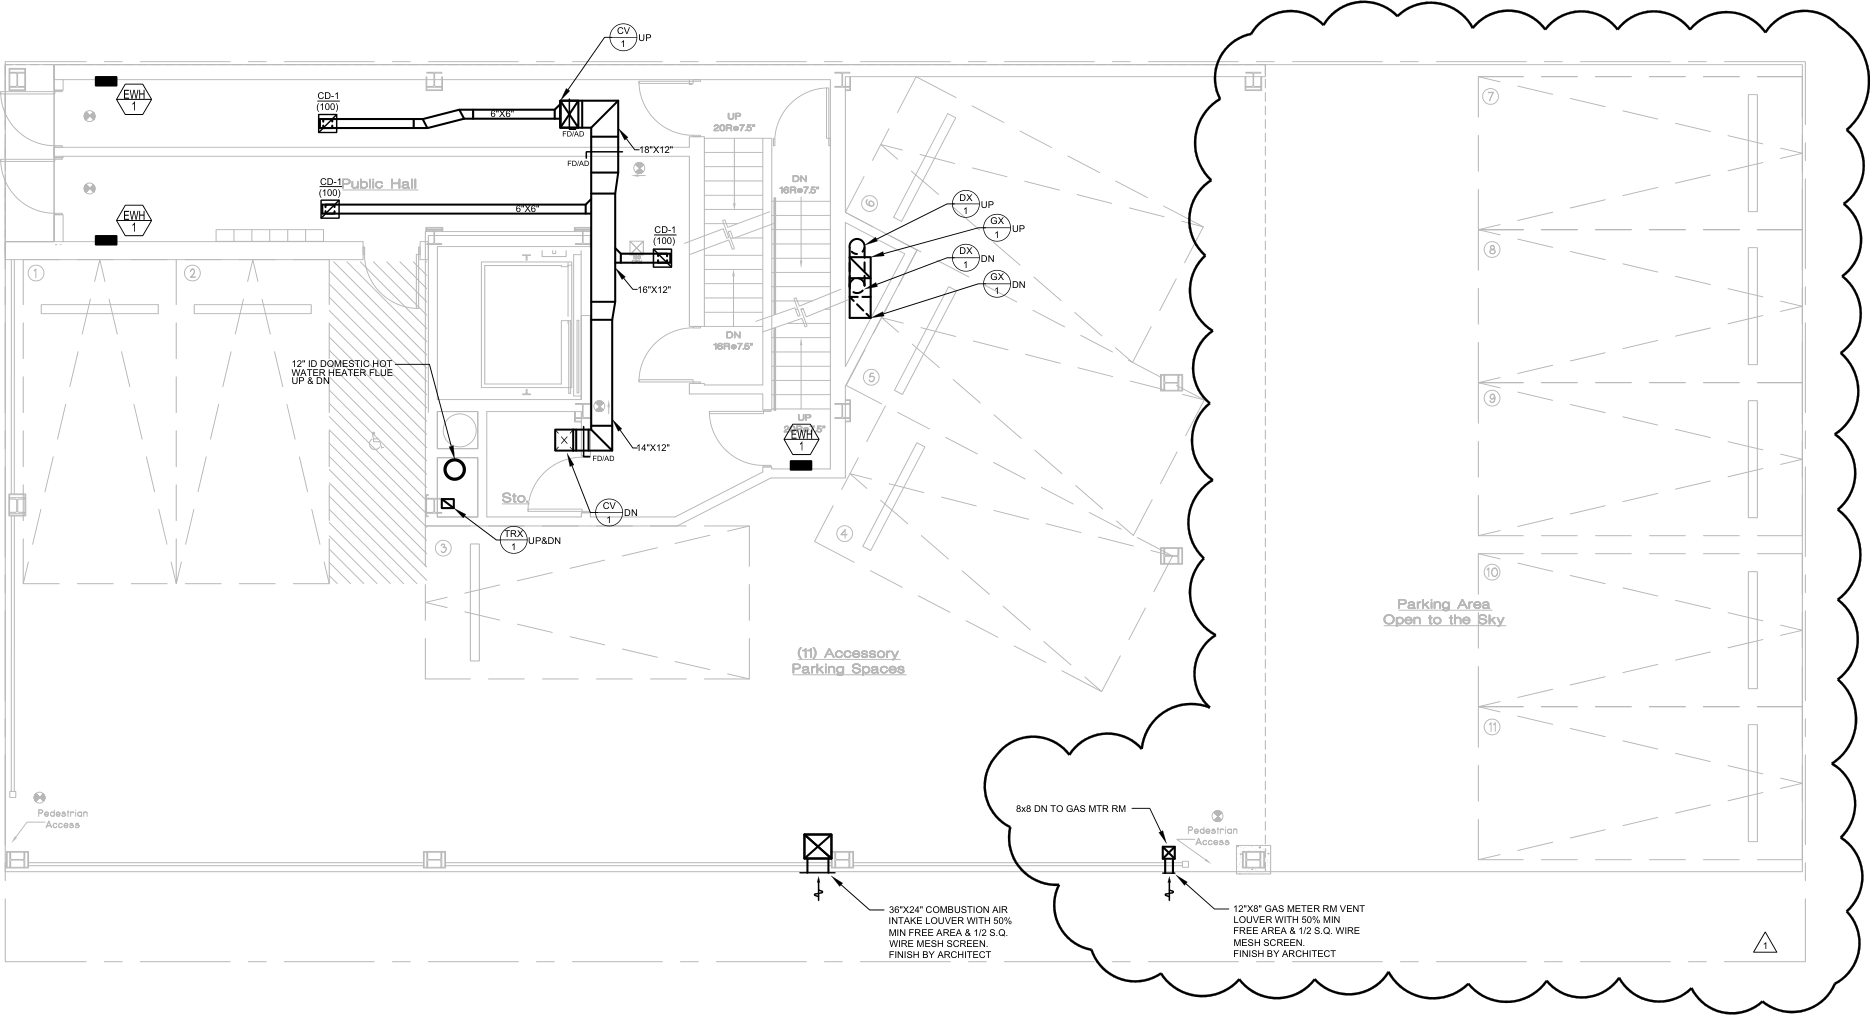

In [138]:
# Load the image using OpenCV
img = cv2.imread("/content/drive/MyDrive/*Datasets/processed_data/page_49.png")
mat_file_path = '/content/drive/MyDrive/*Datasets/ground truth data/page_49_labels.mat'

cv2_imshow(img)

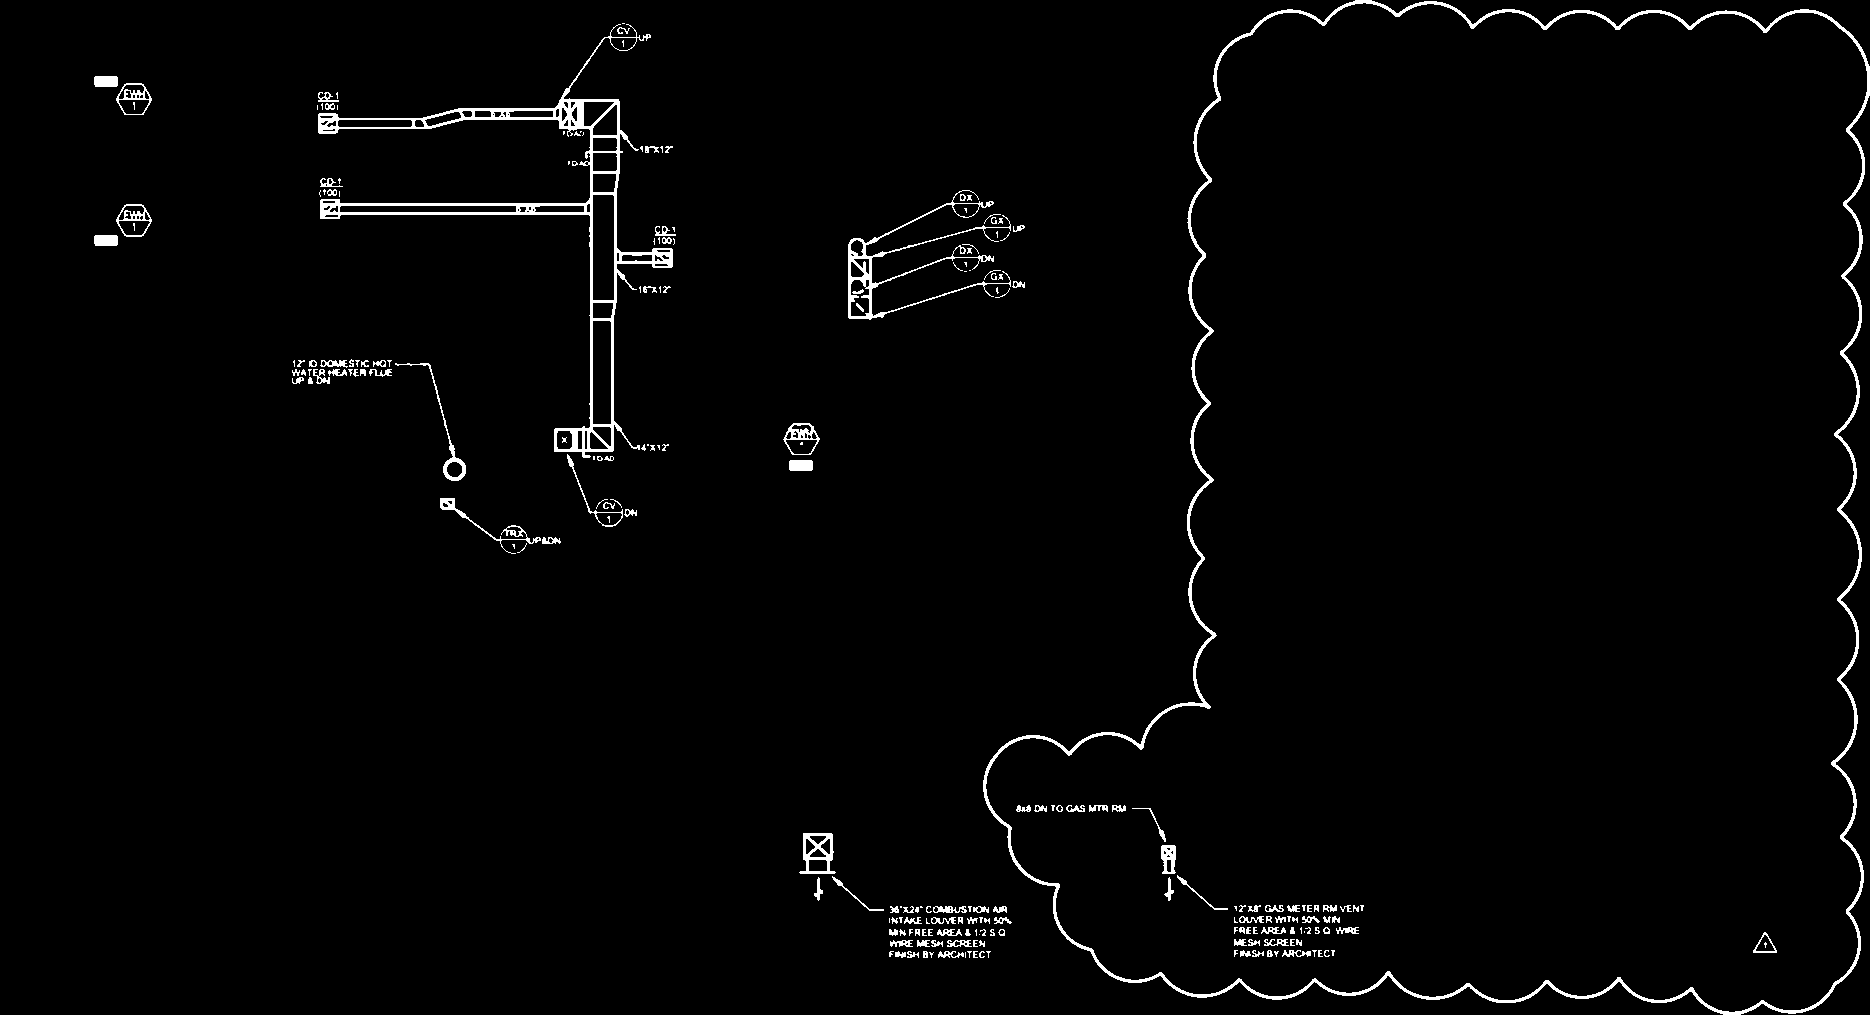

In [139]:
# Preprocess the input image
def preprocess_image(img):
    if len(img.shape) == 3:  # Convert to grayscale if it's a color image
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=1)
    eroded = cv2.erode(closed, kernel, iterations=1)
    dilated = cv2.dilate(eroded, kernel, iterations=1)
    return dilated

dilated = preprocess_image(img)
cv2_imshow(dilated)

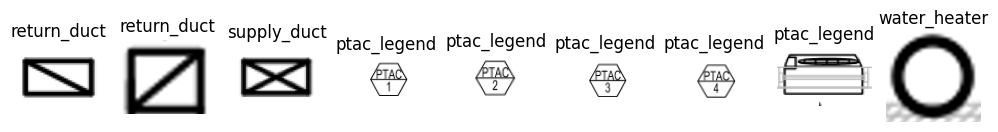

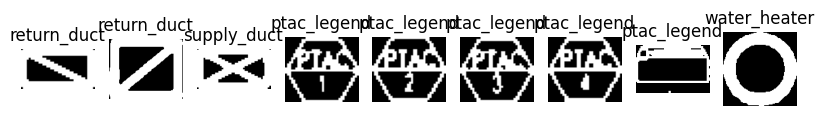

In [140]:
def preprocess_template(template_img):
    # Convert to grayscale if it's a color image
    if len(template_img.shape) == 3:
        gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = template_img

    # Apply Gaussian blur to smooth the image
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    # Apply binary thresholding to create a binary image
    _, binary_img = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)

    # Perform morphological closing to fill gaps
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Erode and dilate to refine the binary mask
    eroded = cv2.erode(closed, kernel, iterations=2)
    refined = cv2.dilate(eroded, kernel, iterations=1)

    # Crop the image to remove surrounding whitespace
    coords = cv2.findNonZero(refined)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        cropped = refined[y:y + h, x:x + w]
    else:
        cropped = refined  # Fallback if no non-zero pixels are found

    return cropped

# Paths for templates
template_paths = [
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Return Air Duct - horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Return Air Duct-v.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Supply Air Duct - horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_1.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_2.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_3.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_4.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Hot Water Heater.png'
]

template_names = [
    'return_duct', 'return_duct',
    'supply_duct',
    'ptac_legend', 'ptac_legend', 'ptac_legend', 'ptac_legend',
    'ptac_legend',
    'water_heater'
]

# Load and preprocess templates
templates = [preprocess_template(cv2.imread(path, 0)) for path in template_paths]

# Plot the original templates before preprocessing
original_templates = [cv2.imread(path) for path in template_paths]  # Load original templates (in color if applicable)

plt.figure(figsize=(10, 5))  # Match the size of the preprocessed template plots
for i, (template, name) in enumerate(zip(original_templates, template_names)):
    if template is not None:  # Handle cases where template could not be loaded
        plt.subplot(1, len(template_names), i + 1)
        plt.imshow(cv2.cvtColor(template, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for correct display
        plt.title(name)  # Title matches the template name
        plt.axis('off')
plt.tight_layout()
plt.show()

# Plot each template using matplotlib
plt.figure(figsize=(10, 5))
for i, (template, name) in enumerate(zip(templates, template_names)):
    plt.subplot(1, len(templates), i + 1)
    plt.imshow(template, cmap='gray')
    plt.title(name)
    plt.axis('off')
plt.show()

In [141]:
# Define a function to preprocess templates and extract contours at specific 90-degree angles
def preprocess_template_with_all_contours(template_img, rotation_angles=[0, 90, 180, 270]):
    processed_templates = []
    for angle in rotation_angles:
        (h, w) = template_img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_template = cv2.warpAffine(template_img, M, (w, h))

        # Preprocess the rotated template
        gray = cv2.GaussianBlur(rotated_template, (3, 3), 0)
        _, binary_img = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
        kernel = np.ones((1, 1), np.uint8)
        processed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=1)
        processed = cv2.erode(processed, kernel, iterations=1)
        processed = cv2.dilate(processed, kernel, iterations=1)

        # Crop the image to remove whitespace
        coords = cv2.findNonZero(processed)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            cropped = processed[y:y+h, x:x+w]

            # Find all contours (both internal and external)
            contours, _ = cv2.findContours(cropped, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                # Combine all contours into one
                combined_contour = np.vstack(contours)
                processed_templates.append((cropped, combined_contour))  # Store template and its combined contour

    return processed_templates

# Function to count edges (vertices) of a contour
def count_contour_edges(contour, epsilon_factor=0.02):
    epsilon = epsilon_factor * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)
    return len(approx)

from collections import defaultdict

# IoU Calculation Function
def calculate_iou(box1, box2):
    """Calculate IoU between two boxes."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_width = max(0, x2 - x1)
    inter_height = max(0, y2 - y1)
    inter_area = inter_width * inter_height

    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    iou = inter_area / (area_box1 + area_box2 - inter_area + 1e-6)  # Avoid division by zero
    return iou

# Improved NMS Implementation
def non_max_suppression(boxes, scores, iou_threshold=0.2):
    """Non-Maximum Suppression with IoU Filtering."""
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes, dtype=np.float32)
    scores = np.array(scores, dtype=np.float32)
    sorted_indices = np.argsort(scores)[::-1]  # Sort scores in descending order

    selected_boxes = []
    while len(sorted_indices) > 0:
        current_index = sorted_indices[0]
        selected_boxes.append(current_index)

        # Calculate IoU for the current box with remaining boxes
        ious = [
            calculate_iou(boxes[current_index], boxes[other_index])
            for other_index in sorted_indices[1:]
        ]

        # Filter out boxes with IoU above the threshold
        sorted_indices = np.delete(
            sorted_indices,
            np.where(np.array(ious) > iou_threshold)[0] + 1
        )

        # Remove the current index
        sorted_indices = sorted_indices[1:]

    return boxes[selected_boxes].astype("int")

# Function to remove intersecting bounding boxes
def remove_intersections(boxes):
    """Remove intersecting bounding boxes from the given list."""
    non_intersecting_boxes = []
    for current_box in boxes:
        keep = True
        current_rect = box(current_box[0], current_box[1], current_box[0] + current_box[2], current_box[1] + current_box[3])
        for other_box in non_intersecting_boxes:
            other_rect = box(other_box[0], other_box[1], other_box[0] + other_box[2], other_box[1] + other_box[3])
            if current_rect.intersects(other_rect):
                keep = False
                break
        if keep:
            non_intersecting_boxes.append(current_box)
    return non_intersecting_boxes


# Match contours using polygon shape matching
def match_contours(template_contour, target_image, similarity_threshold=0.15):
    # Convert the target image to binary (if not already)
    if len(target_image.shape) == 3:
        gray = cv2.cvtColor(target_image, cv2.COLOR_BGR2GRAY)
    else:
        gray = target_image
    _, binary_target = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

    # Find contours in the target image
    contours_target, _ = cv2.findContours(binary_target, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    matched_boxes = []

    for tgt_contour in contours_target:
        # Approximate the target contour to a polygon
        epsilon = 0.01 * cv2.arcLength(tgt_contour, True)
        tgt_poly = cv2.approxPolyDP(tgt_contour, epsilon, True)

        # Match the template polygon to the target polygon
        match_score = cv2.matchShapes(template_contour, tgt_poly, cv2.CONTOURS_MATCH_I1, 0.0)

        # If the match score is below the threshold, add the bounding box
        if match_score < similarity_threshold:
            x, y, w, h = cv2.boundingRect(tgt_poly)
            matched_boxes.append([x, y, x + w, y + h])

    return matched_boxes


In [142]:
# Preprocess templates with rotations at 90-degree increments and extract all contours
all_template_variants = []
for t in templates:
    if t is not None:
        rotated_templates = preprocess_template_with_all_contours(t, rotation_angles=[0, 90, 180, 270])
        all_template_variants.append(rotated_templates)
    else:
        all_template_variants.append([])

# Define the scales and threshold for template matching
scales = [1.0, 0.95, 0.9, 0.85, 0.8]
threshold = 0.7

template_colors = {
    "supply_duct": (255, 0, 0),  # Red
    "return_duct": (0, 255, 0),  # Green
    "ptac_legend": (0, 0, 255),  # Blue
    "water_heater": (255, 255, 0)  # Yellow
}


# Define template-specific thresholds
template_thresholds = {
    'return_duct': 0.7,
    'supply_duct': 0.5,
    'ptac_legend': 0.4,
    'water_heater': 0.6
}

# Initialize the dictionary to store predicted bounding boxes
predicted_boxes = {
    "SupplyDuct": [],
    "ReturnDuct": [],
    "PTAC": [],
    "WaterHeater": []  # Added Water Heater
}

Invariant-Template-Matching: https://github.com/cozheyuanzhangde/Invariant-TemplateMatching


Filtered Bounding Boxes After Removing Intersections:
SupplyDuct: []
ReturnDuct: []
PTAC: []
WaterHeater: []


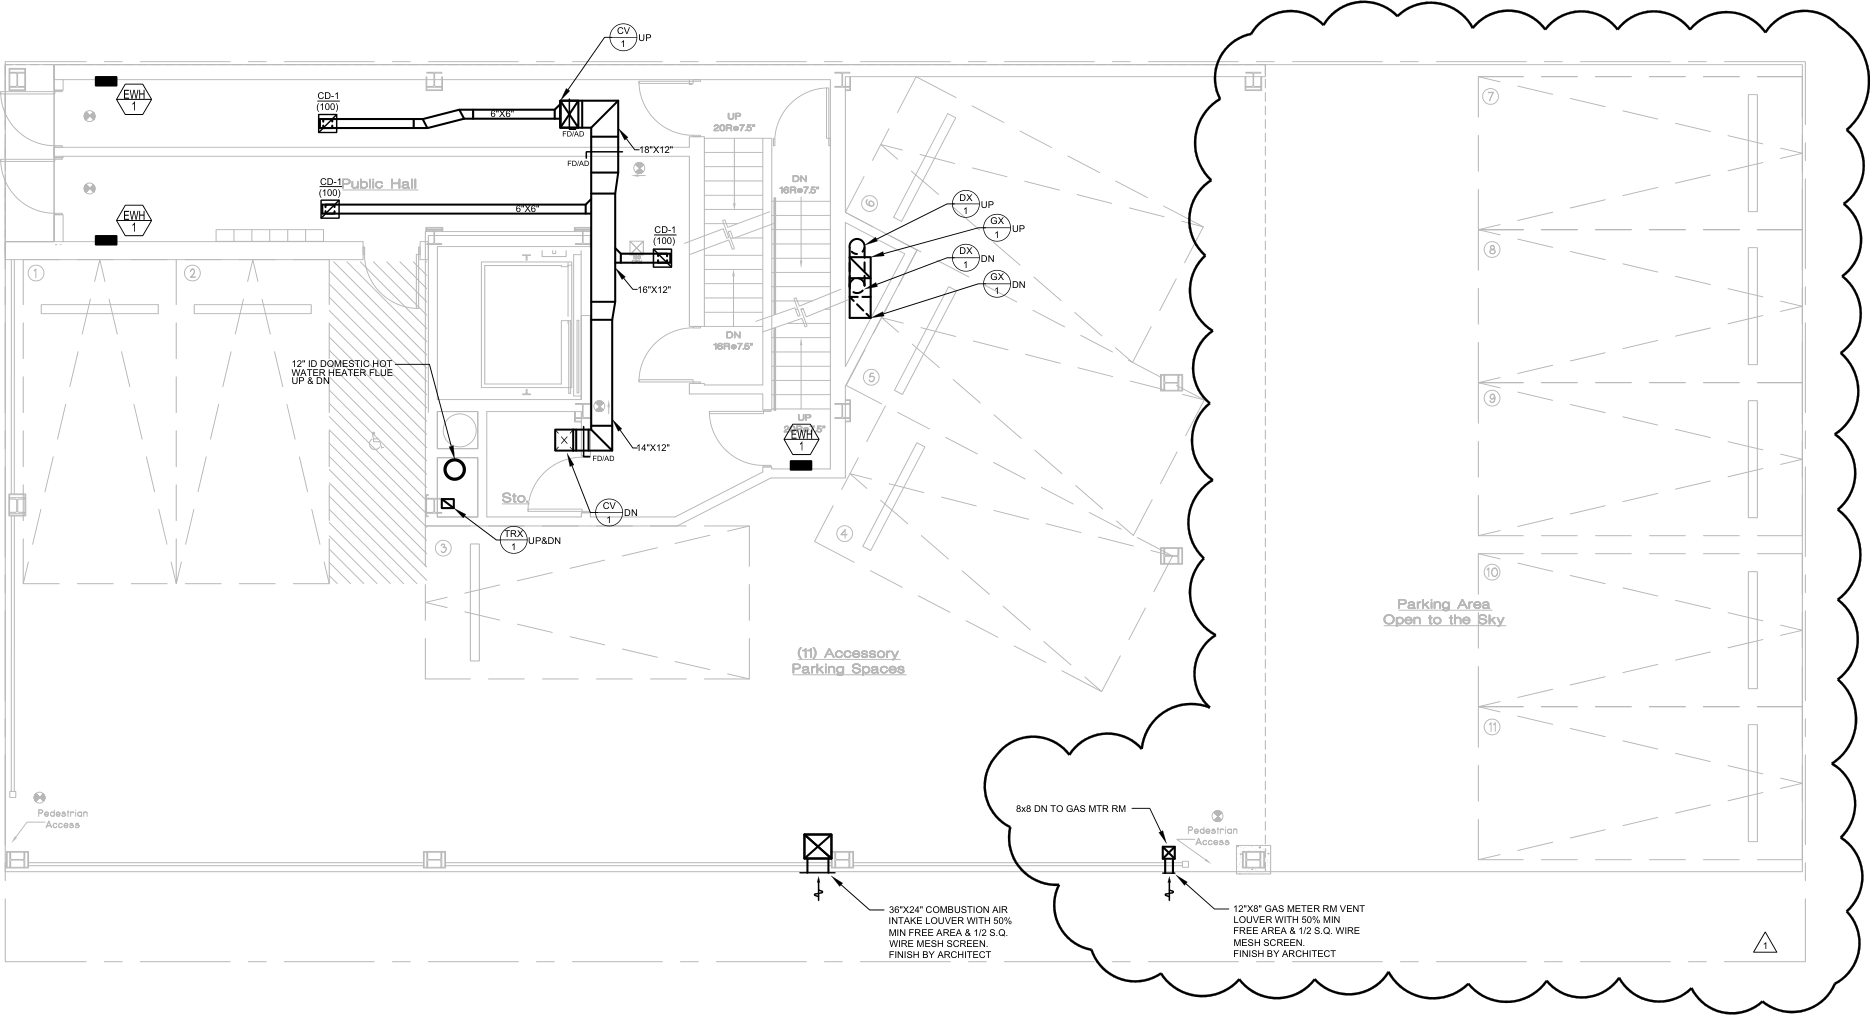

In [143]:
# Initialize storage for unique template matches and scores
unique_template_matches = defaultdict(list)
template_scores = defaultdict(list)

# Loop through each set of template variants
for template_variants, template_name in zip(all_template_variants, template_names):
    for scaled_template, template_contour in template_variants:
        for scale in scales:
            scaled_template_resized = cv2.resize(scaled_template, (0, 0), fx=scale, fy=scale)
            (h, w) = scaled_template_resized.shape[:2]

            # Template matching
            result = cv2.matchTemplate(dilated, scaled_template_resized, cv2.TM_CCOEFF_NORMED)
            (yCoords, xCoords) = np.where(result >= threshold)

            for (x, y) in zip(xCoords, yCoords):
                score = result[y, x]  # Confidence score
                unique_template_matches[template_name].append([x, y, x + w, y + h])
                template_scores[template_name].append(score)

# Initialize storage for combined matches and scores per template type
combined_template_matches = defaultdict(list)
combined_template_scores = defaultdict(list)

# Loop through each template type and aggregate matches across rotations/scales
for template_name in unique_template_matches.keys():
    combined_template_matches[template_name].extend(unique_template_matches[template_name])
    combined_template_scores[template_name].extend(template_scores[template_name])

# Define IoU threshold for NMS
iou_threshold = 0.1  # Adjust this value as needed

# Apply NMS for each template type on combined results
for template_name, boxes in combined_template_matches.items():
    if not boxes:
        continue

    # Convert bounding boxes and scores to numpy arrays
    boxes_np = np.array(boxes)
    scores_np = np.array(combined_template_scores[template_name])

    # Apply NMS to remove overlapping boxes
    filtered_boxes = non_max_suppression(boxes_np, scores_np, iou_threshold)

    # Store filtered bounding boxes
    for (startX, startY, endX, endY) in filtered_boxes:
        width, height = endX - startX, endY - startY
        if template_name == "supply_duct":
            predicted_boxes["SupplyDuct"].append([startX, startY, width, height])
        elif template_name == "return_duct":
            predicted_boxes["ReturnDuct"].append([startX, startY, width, height])
        elif template_name == "ptac_legend":
            predicted_boxes["PTAC"].append([startX, startY, width, height])
        elif template_name == "water_heater":
            predicted_boxes["WaterHeater"].append([startX, startY, width, height])

# Apply the remove_intersections function to the predicted boxes
for label, boxes in predicted_boxes.items():
    predicted_boxes[label] = remove_intersections(boxes)

# Debugging: Print filtered bounding boxes after removing intersections
print("\nFiltered Bounding Boxes After Removing Intersections:")
for label, boxes in predicted_boxes.items():
    print(f"{label}: {boxes}")

# Redraw the final image with filtered bounding boxes
cleaned_image = img.copy()

for label, boxes in predicted_boxes.items():
    color = template_colors.get(label.lower(), (0, 255, 0))  # Retrieve consistent color for the label
    for (x, y, w, h) in boxes:
        cv2.rectangle(cleaned_image, (x, y), (x + w, y + h), color, 2)
        cv2.putText(cleaned_image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# Display the cleaned image with updated bounding boxes
cv2_imshow(cleaned_image)


Evaluate object detection using ground-truth-labeled image from MATLAB image labeler.

In [144]:
from scipy.io import loadmat

# Load the .mat file
mat_data = loadmat(mat_file_path)

# Inspect the keys to identify the structure
print("Keys in the .mat file:", mat_data.keys())

# Extract the struct
labels_struct = mat_data['labelsStruct']  # Adjust based on the key name

# Parse bounding boxes for each label type
def parse_bounding_boxes(bbox_array):
    """Converts MATLAB bounding boxes to Python-friendly lists."""
    if bbox_array.size == 0:
        return []  # Return empty if no bounding boxes
    if isinstance(bbox_array, np.ndarray):
        # Case 1: Directly in (N, 4) format
        if bbox_array.ndim == 2 and bbox_array.shape[1] == 4:
            return bbox_array.tolist()
        # Case 2: Single bounding box as a flat array (e.g., [x, y, width, height])
        elif bbox_array.ndim == 1 and bbox_array.size == 4:
            return [bbox_array.tolist()]
        # Case 3: Nested or irregular single bounding box
        elif bbox_array.ndim == 2 and bbox_array.shape[0] == 1 and bbox_array.shape[1] == 1:
            # Drill down into the nested array and reshape
            nested_bbox = bbox_array[0, 0]
            if nested_bbox.ndim == 1 and nested_bbox.size == 4:
                return [nested_bbox.tolist()]
            elif nested_bbox.ndim == 2 and nested_bbox.shape[1] == 4:
                return nested_bbox.tolist()
        # Case 4: Reshape flat array into (N, 4)
        try:
            return bbox_array.reshape(-1, 4).tolist()
        except ValueError:
            pass  # Fall through to empty return if reshaping fails
    return []  # Default return for unrecognized formats


# Parse ground truth bounding boxes
parsed_labels = []
for row in labels_struct:
    supply_duct, return_duct, ptac, water_heater = row[0]
    parsed_labels.append({
        "SupplyDuct": parse_bounding_boxes(supply_duct),
        "ReturnDuct": parse_bounding_boxes(return_duct),
        "PTAC": parse_bounding_boxes(ptac),
        "WaterHeater": parse_bounding_boxes(water_heater)  # Added Water Heater
    })

ground_truth_boxes = parsed_labels[0]
supply_duct_boxes = ground_truth_boxes["SupplyDuct"]
return_duct_boxes = ground_truth_boxes["ReturnDuct"]
ptac_boxes = ground_truth_boxes["PTAC"]
water_heater_boxes = ground_truth_boxes["WaterHeater"]  # Added Water Heater

# Display parsed bounding boxes
print("")
print("SupplyDuct bounding boxes:", supply_duct_boxes)
print("ReturnDuct bounding boxes:", return_duct_boxes)
print("PTAC bounding boxes:", ptac_boxes)
print("WaterHeater bounding boxes:", water_heater_boxes)


Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'labelsStruct'])

SupplyDuct bounding boxes: [[553, 425, 24, 30], [803, 832, 33, 33]]
ReturnDuct bounding boxes: [[441, 498, 17, 14]]
PTAC bounding boxes: []
WaterHeater bounding boxes: [[443, 459, 25, 24]]


In [145]:
def calculate_iou(gt_box, pred_box):
    gt = box(gt_box[0], gt_box[1], gt_box[0] + gt_box[2], gt_box[1] + gt_box[3])
    pred = box(pred_box[0], pred_box[1], pred_box[0] + pred_box[2], pred_box[1] + pred_box[3])

    intersection = gt.intersection(pred).area
    union = gt.union(pred).area

    return intersection / union if union > 0 else 0

def match_predictions(gt_boxes, pred_boxes, iou_threshold):
    """Matches predictions to ground truth boxes based on IoU."""
    matches = []
    for gt in gt_boxes:
        for pred in pred_boxes:
            iou = calculate_iou(gt, pred)
            if iou >= iou_threshold:
                matches.append((gt, pred, iou))
    return matches

def calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold):
    """Calculates precision and recall for a single label type."""
    matches = match_predictions(gt_boxes, pred_boxes, iou_threshold)

    true_positives = len(matches)
    false_positives = len(pred_boxes) - true_positives
    false_negatives = len(gt_boxes) - true_positives

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

    return precision, recall


In [146]:
for label_type in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]:  # Added Water Heater
    gt_boxes = ground_truth_boxes[label_type]
    pred_boxes = predicted_boxes[label_type]

    precision, recall = calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold)
    print(f"{label_type} Evaluation:")
    print(f"  Precision: {precision:.2f}")
    print(f"  Recall: {recall:.2f}")
    print("")


SupplyDuct Evaluation:
  Precision: 0.00
  Recall: 0.00

ReturnDuct Evaluation:
  Precision: 0.00
  Recall: 0.00

PTAC Evaluation:
  Precision: 0.00
  Recall: 0.00

WaterHeater Evaluation:
  Precision: 0.00
  Recall: 0.00



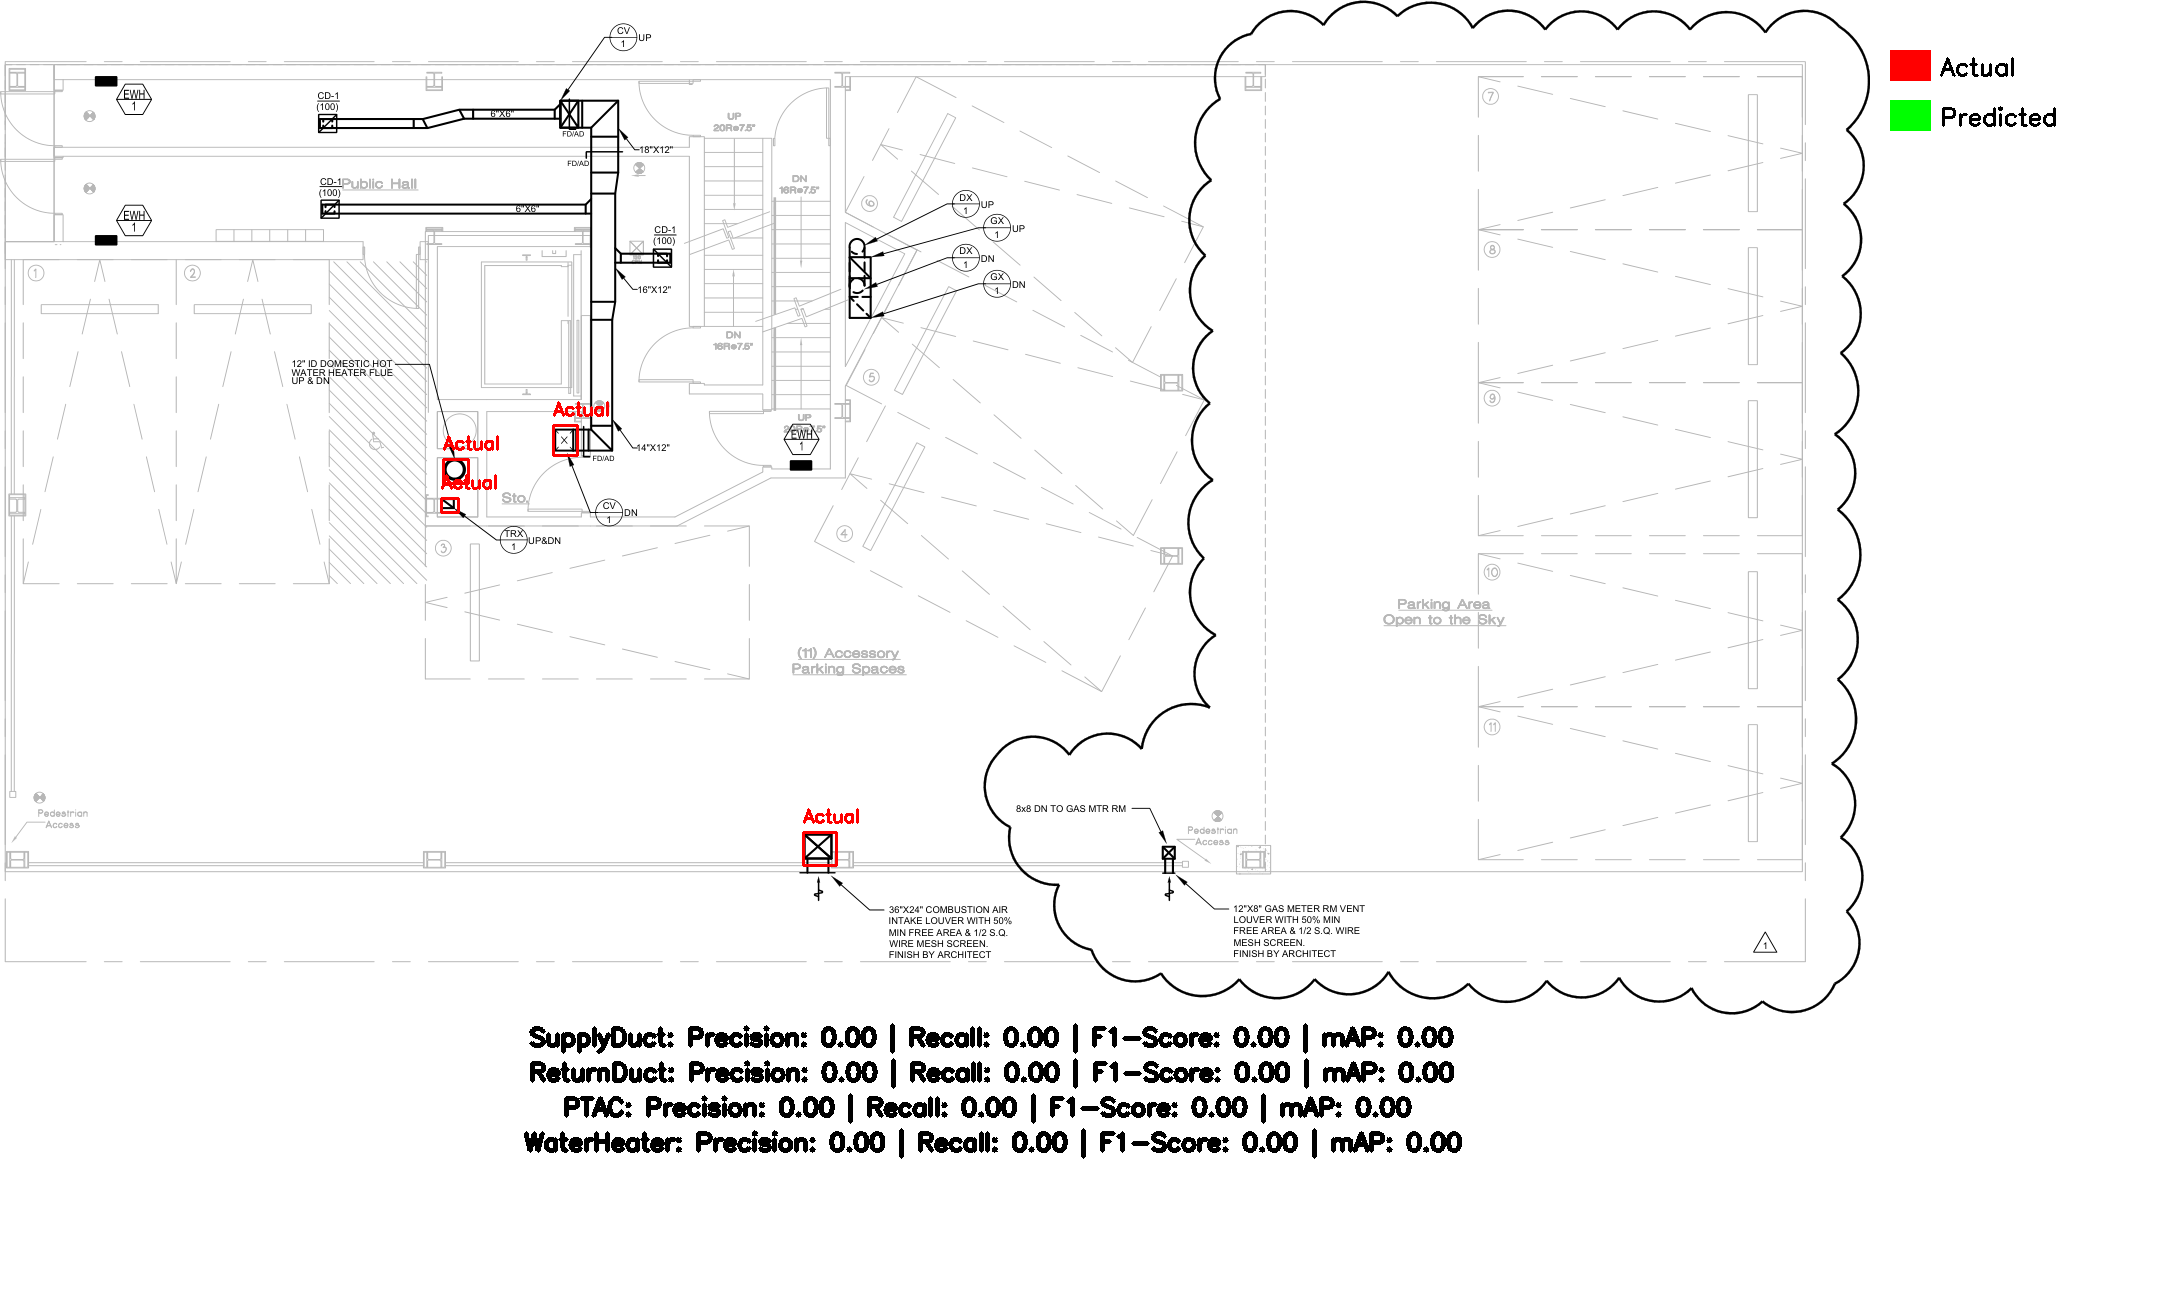

In [147]:
# Colors for visualization (BGR format for OpenCV)
colors = {
    "Actual": (0, 0, 255),  # Red for Ground Truth
    "Predicted": (0, 255, 0),  # Green for Predictions
}

# Function to draw bounding boxes
def draw_boxes(image, boxes, color, label):
    for box in boxes:
        x, y, w, h = box
        cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
        cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Function to calculate IoU and annotate
def annotate_iou(image, gt_boxes, pred_boxes, color, iou_threshold):
    for gt in gt_boxes:
        for pred in pred_boxes:
            iou = calculate_iou(gt, pred)
            if iou >= iou_threshold:
                cv2.putText(
                    image,
                    f"IoU: {iou:.2f}",
                    (pred[0], pred[1] - 20),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    color,
                    2,
                )

# Function to calculate mAP (mean Average Precision)
def calculate_map(gt_boxes, pred_boxes, iou_threshold):
    matches = match_predictions(gt_boxes, pred_boxes, iou_threshold)
    true_positives = len(matches)
    false_positives = len(pred_boxes) - true_positives
    false_negatives = len(gt_boxes) - true_positives

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

    # Use average precision (AP) formula
    ap = (precision + recall) / 2 if precision > 0 or recall > 0 else 0
    return ap

# Create a copy of the image for visualization
visualized_image = img.copy()

# Visualize bounding boxes for ground truth and predictions
for label_type in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]:
    gt_boxes = ground_truth_boxes[label_type]
    pred_boxes = predicted_boxes[label_type]

    # Draw GT (Actual) and Predicted boxes
    draw_boxes(visualized_image, gt_boxes, colors["Actual"], "Actual")
    draw_boxes(visualized_image, pred_boxes, colors["Predicted"], "Predicted")

    # Annotate IoU for matches
    annotate_iou(visualized_image, gt_boxes, pred_boxes, colors["Predicted"], iou_threshold)

# Dynamically adjust bottom padding for metrics
num_metrics = len(["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"])  # Number of templates
bottom_padding = num_metrics * 70  # Adjust height dynamically based on number of metrics

# Add space for the legend and metrics
legend_width = 300
canvas = np.ones(
    (visualized_image.shape[0] + bottom_padding, visualized_image.shape[1] + legend_width, 3),
    dtype=np.uint8,
) * 255
canvas[: visualized_image.shape[0], : visualized_image.shape[1]] = visualized_image

# Add legend on the right
legend_y_start = 50
legend_y_step = 50
for idx, (label, color) in enumerate(colors.items()):
    y_pos = legend_y_start + idx * legend_y_step
    cv2.rectangle(canvas, (visualized_image.shape[1] + 20, y_pos), (visualized_image.shape[1] + 60, y_pos + 30), color, -1)
    cv2.putText(canvas, label, (visualized_image.shape[1] + 70, y_pos + 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

# Add metrics at the bottom center
metrics_text_y = visualized_image.shape[0] + 30
for idx, label_type in enumerate(["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]):  # Added Water Heater
    gt_boxes = ground_truth_boxes[label_type]
    pred_boxes = predicted_boxes[label_type]

    # Calculate metrics
    precision, recall = calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold)
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    map_score = calculate_map(gt_boxes, pred_boxes, iou_threshold)

    # Format metrics text with `|` separators
    label = (
        f"{label_type}: Precision: {precision:.2f} | Recall: {recall:.2f} | "
        f"F1-Score: {f1_score:.2f} | mAP: {map_score:.2f}"
    )
    text_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
    text_x = (canvas.shape[1] - legend_width - text_size[0]) // 2
    cv2.putText(
        canvas,
        label,
        (text_x, metrics_text_y + idx * 35),  # Increased spacing between lines
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,  # Slightly larger font size
        (0, 0, 0), 3,  # Boldened text with a thicker outline
    )

# Show the visualization
cv2_imshow(canvas)


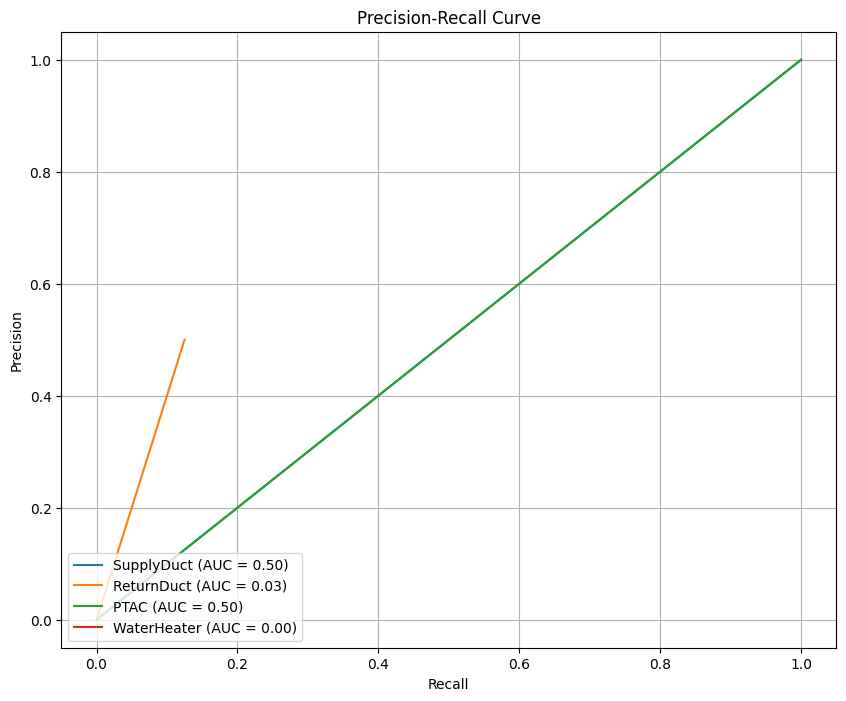

SupplyDuct AUC: 0.50
ReturnDuct AUC: 0.03
PTAC AUC: 0.50
WaterHeater AUC: 0.00


In [104]:
from sklearn.metrics import auc

# Function to calculate precision and recall at multiple IoU thresholds
def calculate_precision_recall_curve(gt_boxes, pred_boxes, iou_thresholds):
    precisions = []
    recalls = []
    for iou_threshold in iou_thresholds:
        precision, recall = calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold)
        precisions.append(precision)
        recalls.append(recall)
    return precisions, recalls

# Define IoU thresholds
iou_thresholds = np.linspace(0.1, 0.9, 9)

# Initialize dictionary to store AUC values
auc_values = {}

# Plot Precision-Recall Curves for each label type
plt.figure(figsize=(10, 8))
for label_type in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]:  # Added Water Heater
    gt_boxes = ground_truth_boxes[label_type]
    pred_boxes = predicted_boxes[label_type]

    # Calculate precision and recall at different IoU thresholds
    precisions, recalls = calculate_precision_recall_curve(gt_boxes, pred_boxes, iou_thresholds)

    # Calculate AUC
    pr_auc = auc(recalls, precisions)
    auc_values[label_type] = pr_auc

    # Plot the Precision-Recall Curve
    plt.plot(recalls, precisions, label=f"{label_type} (AUC = {pr_auc:.2f})")

# Customize the plot
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# Print the AUC values for each label type
for label_type, pr_auc in auc_values.items():
    print(f"{label_type} AUC: {pr_auc:.2f}")

## Matching Threshold Evaluation

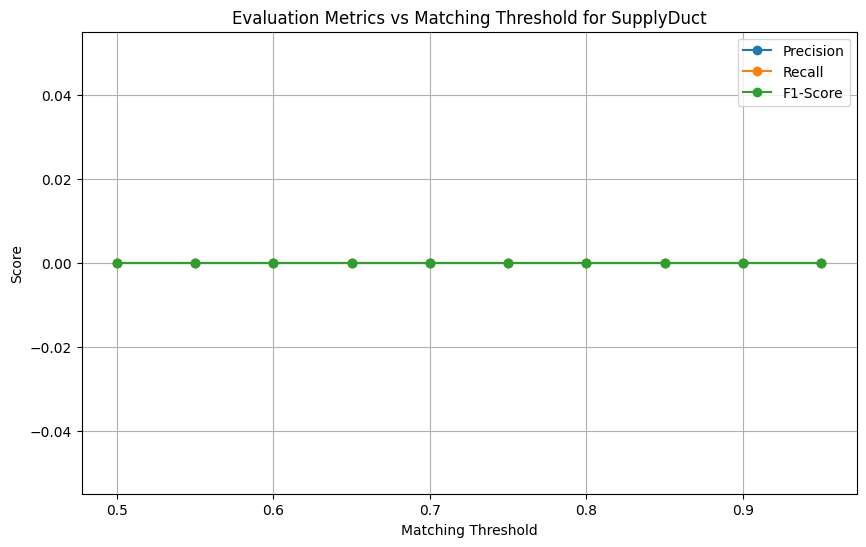

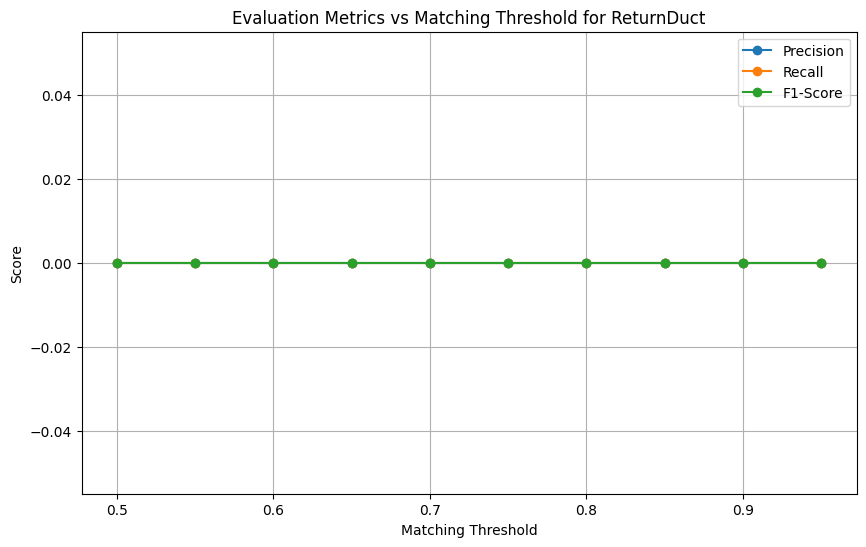

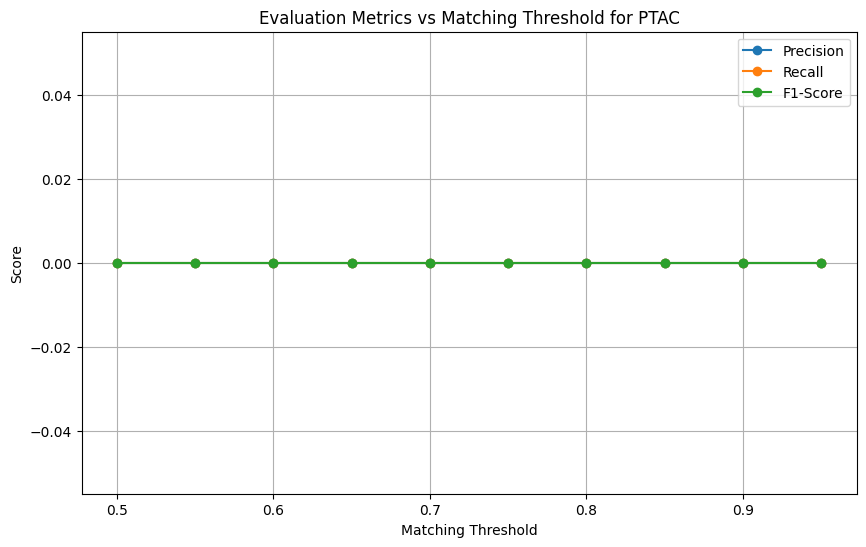

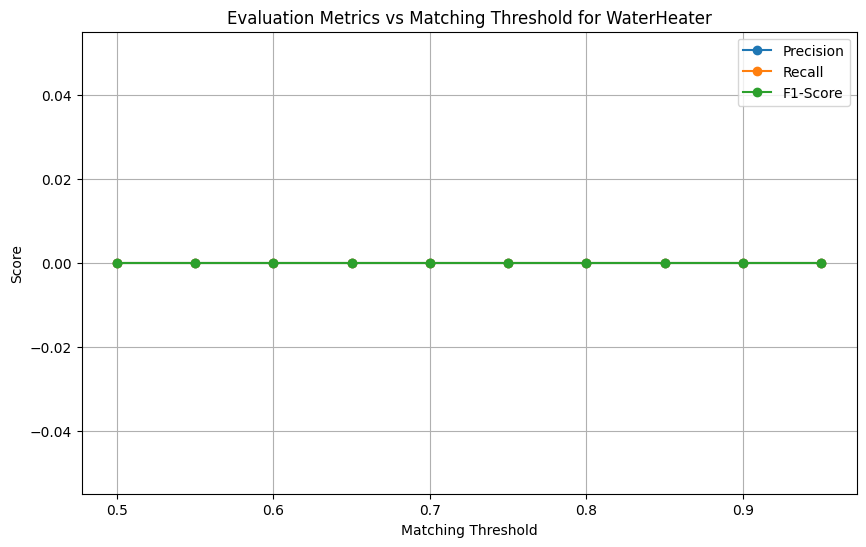


Full Evaluation Results:
    Threshold    LabelType  Precision  Recall  F1Score  CorrectMatches
0        0.50   SupplyDuct          0     0.0        0               0
1        0.50   ReturnDuct          0     0.0        0               0
2        0.50         PTAC          0     0.0        0               0
3        0.50  WaterHeater          0     0.0        0               0
4        0.55   SupplyDuct          0     0.0        0               0
5        0.55   ReturnDuct          0     0.0        0               0
6        0.55         PTAC          0     0.0        0               0
7        0.55  WaterHeater          0     0.0        0               0
8        0.60   SupplyDuct          0     0.0        0               0
9        0.60   ReturnDuct          0     0.0        0               0
10       0.60         PTAC          0     0.0        0               0
11       0.60  WaterHeater          0     0.0        0               0
12       0.65   SupplyDuct          0     0.0      

In [134]:
# Initialize range of matching thresholds to evaluate
matching_thresholds = np.arange(0.5, 1.0, 0.05)  # Adjust threshold range as needed
iou_threshold = 0.1  # Define IoU threshold for matching
evaluation_results = []

# Loop through each threshold
for threshold in matching_thresholds:
    # Initialize storage for unique template matches and scores at this threshold
    unique_template_matches = defaultdict(list)
    template_scores = defaultdict(list)

    # Loop through each set of template variants
    for template_variants, template_name in zip(all_template_variants, template_names):
        for scaled_template, template_contour in template_variants:
            for scale in scales:
                # Resize the template
                scaled_template_resized = cv2.resize(scaled_template, (0, 0), fx=scale, fy=scale)
                (h, w) = scaled_template_resized.shape[:2]

                # Template matching
                result = cv2.matchTemplate(dilated, scaled_template_resized, cv2.TM_CCOEFF_NORMED)
                (yCoords, xCoords) = np.where(result >= threshold)  # Apply the threshold here

                # Store matches and scores
                for (x, y) in zip(xCoords, yCoords):
                    score = result[y, x]  # Confidence score
                    unique_template_matches[template_name].append([x, y, x + w, y + h])
                    template_scores[template_name].append(score)

    # Initialize combined matches and scores for this threshold
    combined_template_matches = defaultdict(list)
    combined_template_scores = defaultdict(list)

    # Aggregate matches across rotations/scales
    for template_name in unique_template_matches.keys():
        combined_template_matches[template_name].extend(unique_template_matches[template_name])
        combined_template_scores[template_name].extend(template_scores[template_name])

    # Apply Non-Max Suppression (NMS) and evaluate precision/recall for each label type
    predicted_boxes = defaultdict(list)  # Reset predictions for each threshold
    for template_name, boxes in combined_template_matches.items():
        if not boxes:
            continue
        # Convert bounding boxes and scores to numpy arrays
        boxes_np = np.array(boxes)
        scores_np = np.array(combined_template_scores[template_name])
        if len(boxes_np) > 0:
            filtered_boxes = non_max_suppression(boxes_np, scores_np, iou_threshold)
            predicted_boxes[template_name].extend(
                [[x1, y1, x2 - x1, y2 - y1] for (x1, y1, x2, y2) in filtered_boxes]
            )

    # Evaluate performance for each label type
    for label_type in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]:
        gt_boxes = ground_truth_boxes[label_type]
        pred_boxes = predicted_boxes.get(label_type, [])

        # Match predictions to ground truth
        matches = match_predictions(gt_boxes, pred_boxes, iou_threshold)

        # Calculate precision and recall
        precision, recall = calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold)

        # Calculate F1-score
        f1_score = (
            2 * (precision * recall) / (precision + recall)
            if (precision + recall) > 0
            else 0
        )

        # Store results for the label type
        evaluation_results.append({
            "Threshold": threshold,
            "LabelType": label_type,
            "Precision": precision,
            "Recall": recall,
            "F1Score": f1_score,
            "CorrectMatches": len(matches),
        })

# Convert evaluation results to a DataFrame
results_df = pd.DataFrame(evaluation_results)

# Plot metrics for each label type across thresholds
for label_type in ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]:
    label_data = results_df[results_df["LabelType"] == label_type]

    plt.figure(figsize=(10, 6))
    plt.plot(label_data["Threshold"], label_data["Precision"], label='Precision', marker='o')
    plt.plot(label_data["Threshold"], label_data["Recall"], label='Recall', marker='o')
    plt.plot(label_data["Threshold"], label_data["F1Score"], label='F1-Score', marker='o')
    plt.title(f"Evaluation Metrics vs Matching Threshold for {label_type}")
    plt.xlabel("Matching Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid()
    plt.show()

# Display the full evaluation results
print("\nFull Evaluation Results:")
print(results_df)


## IoU Threshold Distribtions vs Precision/Recall

*Which IoU threshold value to choose?*

In [106]:
# Function to compute Precision, Recall, and F1-Score
def compute_metrics(predicted_boxes, ground_truth_boxes, iou_threshold):
    tp = 0  # True Positives
    fp = 0  # False Positives
    fn = 0  # False Negatives

    matched_gt = set()

    for pred_box in predicted_boxes:
        match_found = False
        for i, gt_box in enumerate(ground_truth_boxes):
            if i in matched_gt:  # Skip already matched ground truth boxes
                continue
            iou = calculate_iou(gt_box, pred_box)
            if iou >= iou_threshold:
                tp += 1
                matched_gt.add(i)
                match_found = True
                break
        if not match_found:
            fp += 1

    fn = len(ground_truth_boxes) - len(matched_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score

# Function to compute IoU distribution
def compute_iou_distribution(predicted_boxes, ground_truth_boxes):
    iou_values = []
    for pred_box in predicted_boxes:
        best_iou = 0
        for gt_box in ground_truth_boxes:
            iou = calculate_iou(gt_box, pred_box)
            best_iou = max(best_iou, iou)
        iou_values.append(best_iou)
    return iou_values

# Function for parameter sensitivity analysis (Precision, Recall, F1-Score)
def parameter_sensitivity_analysis(predicted_boxes, ground_truth_boxes, iou_thresholds):
    precisions = []
    recalls = []
    f1_scores = []

    for threshold in iou_thresholds:
        precision, recall, f1 = compute_metrics(predicted_boxes, ground_truth_boxes, iou_threshold=threshold)
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

    return precisions, recalls, f1_scores

# Function to plot metrics per template with proper labels
def plot_template_metrics(predicted_boxes, ground_truth_boxes, template_names, iou_thresholds):
    num_templates = len(template_names)
    fig, axes = plt.subplots(num_templates, 2, figsize=(18, 6 * num_templates))

    for idx, template_name in enumerate(template_names):
        pred_boxes = predicted_boxes[template_name]
        gt_boxes = ground_truth_boxes[template_name]

        # Compute IoU distribution
        iou_distribution = compute_iou_distribution(pred_boxes, gt_boxes)

        # Plot IoU distribution
        axes[idx, 0].hist(iou_distribution, bins=10, range=(0, 1), color="skyblue", edgecolor="black")
        axes[idx, 0].set_title(f"{template_name} IoU Distribution", fontsize=14)
        axes[idx, 0].set_xlabel("IoU", fontsize=12)
        axes[idx, 0].set_ylabel("Frequency", fontsize=12)
        axes[idx, 0].grid(True, linestyle="--", alpha=0.6)

        # Perform sensitivity analysis
        precisions, recalls, f1_scores = parameter_sensitivity_analysis(pred_boxes, gt_boxes, iou_thresholds)

        # Plot Precision, Recall, and F1-Score vs IoU threshold
        axes[idx, 1].plot(iou_thresholds, precisions, label="Precision", marker="o", linestyle="--")
        axes[idx, 1].plot(iou_thresholds, recalls, label="Recall", marker="s", linestyle="--")
        axes[idx, 1].plot(iou_thresholds, f1_scores, label="F1-Score", marker="^", linestyle="--")
        axes[idx, 1].set_title(f"{template_name} Metrics vs IoU Threshold", fontsize=14)
        axes[idx, 1].set_xlabel("IoU Threshold", fontsize=12)
        axes[idx, 1].set_ylabel("Metric Value", fontsize=12)
        axes[idx, 1].legend(loc="lower left", fontsize=10)
        axes[idx, 1].grid(True, linestyle="--", alpha=0.6)
        axes[idx, 1].set_xticks(iou_thresholds)
        axes[idx, 1].set_ylim(0, 1.0)

    plt.tight_layout()
    plt.show()

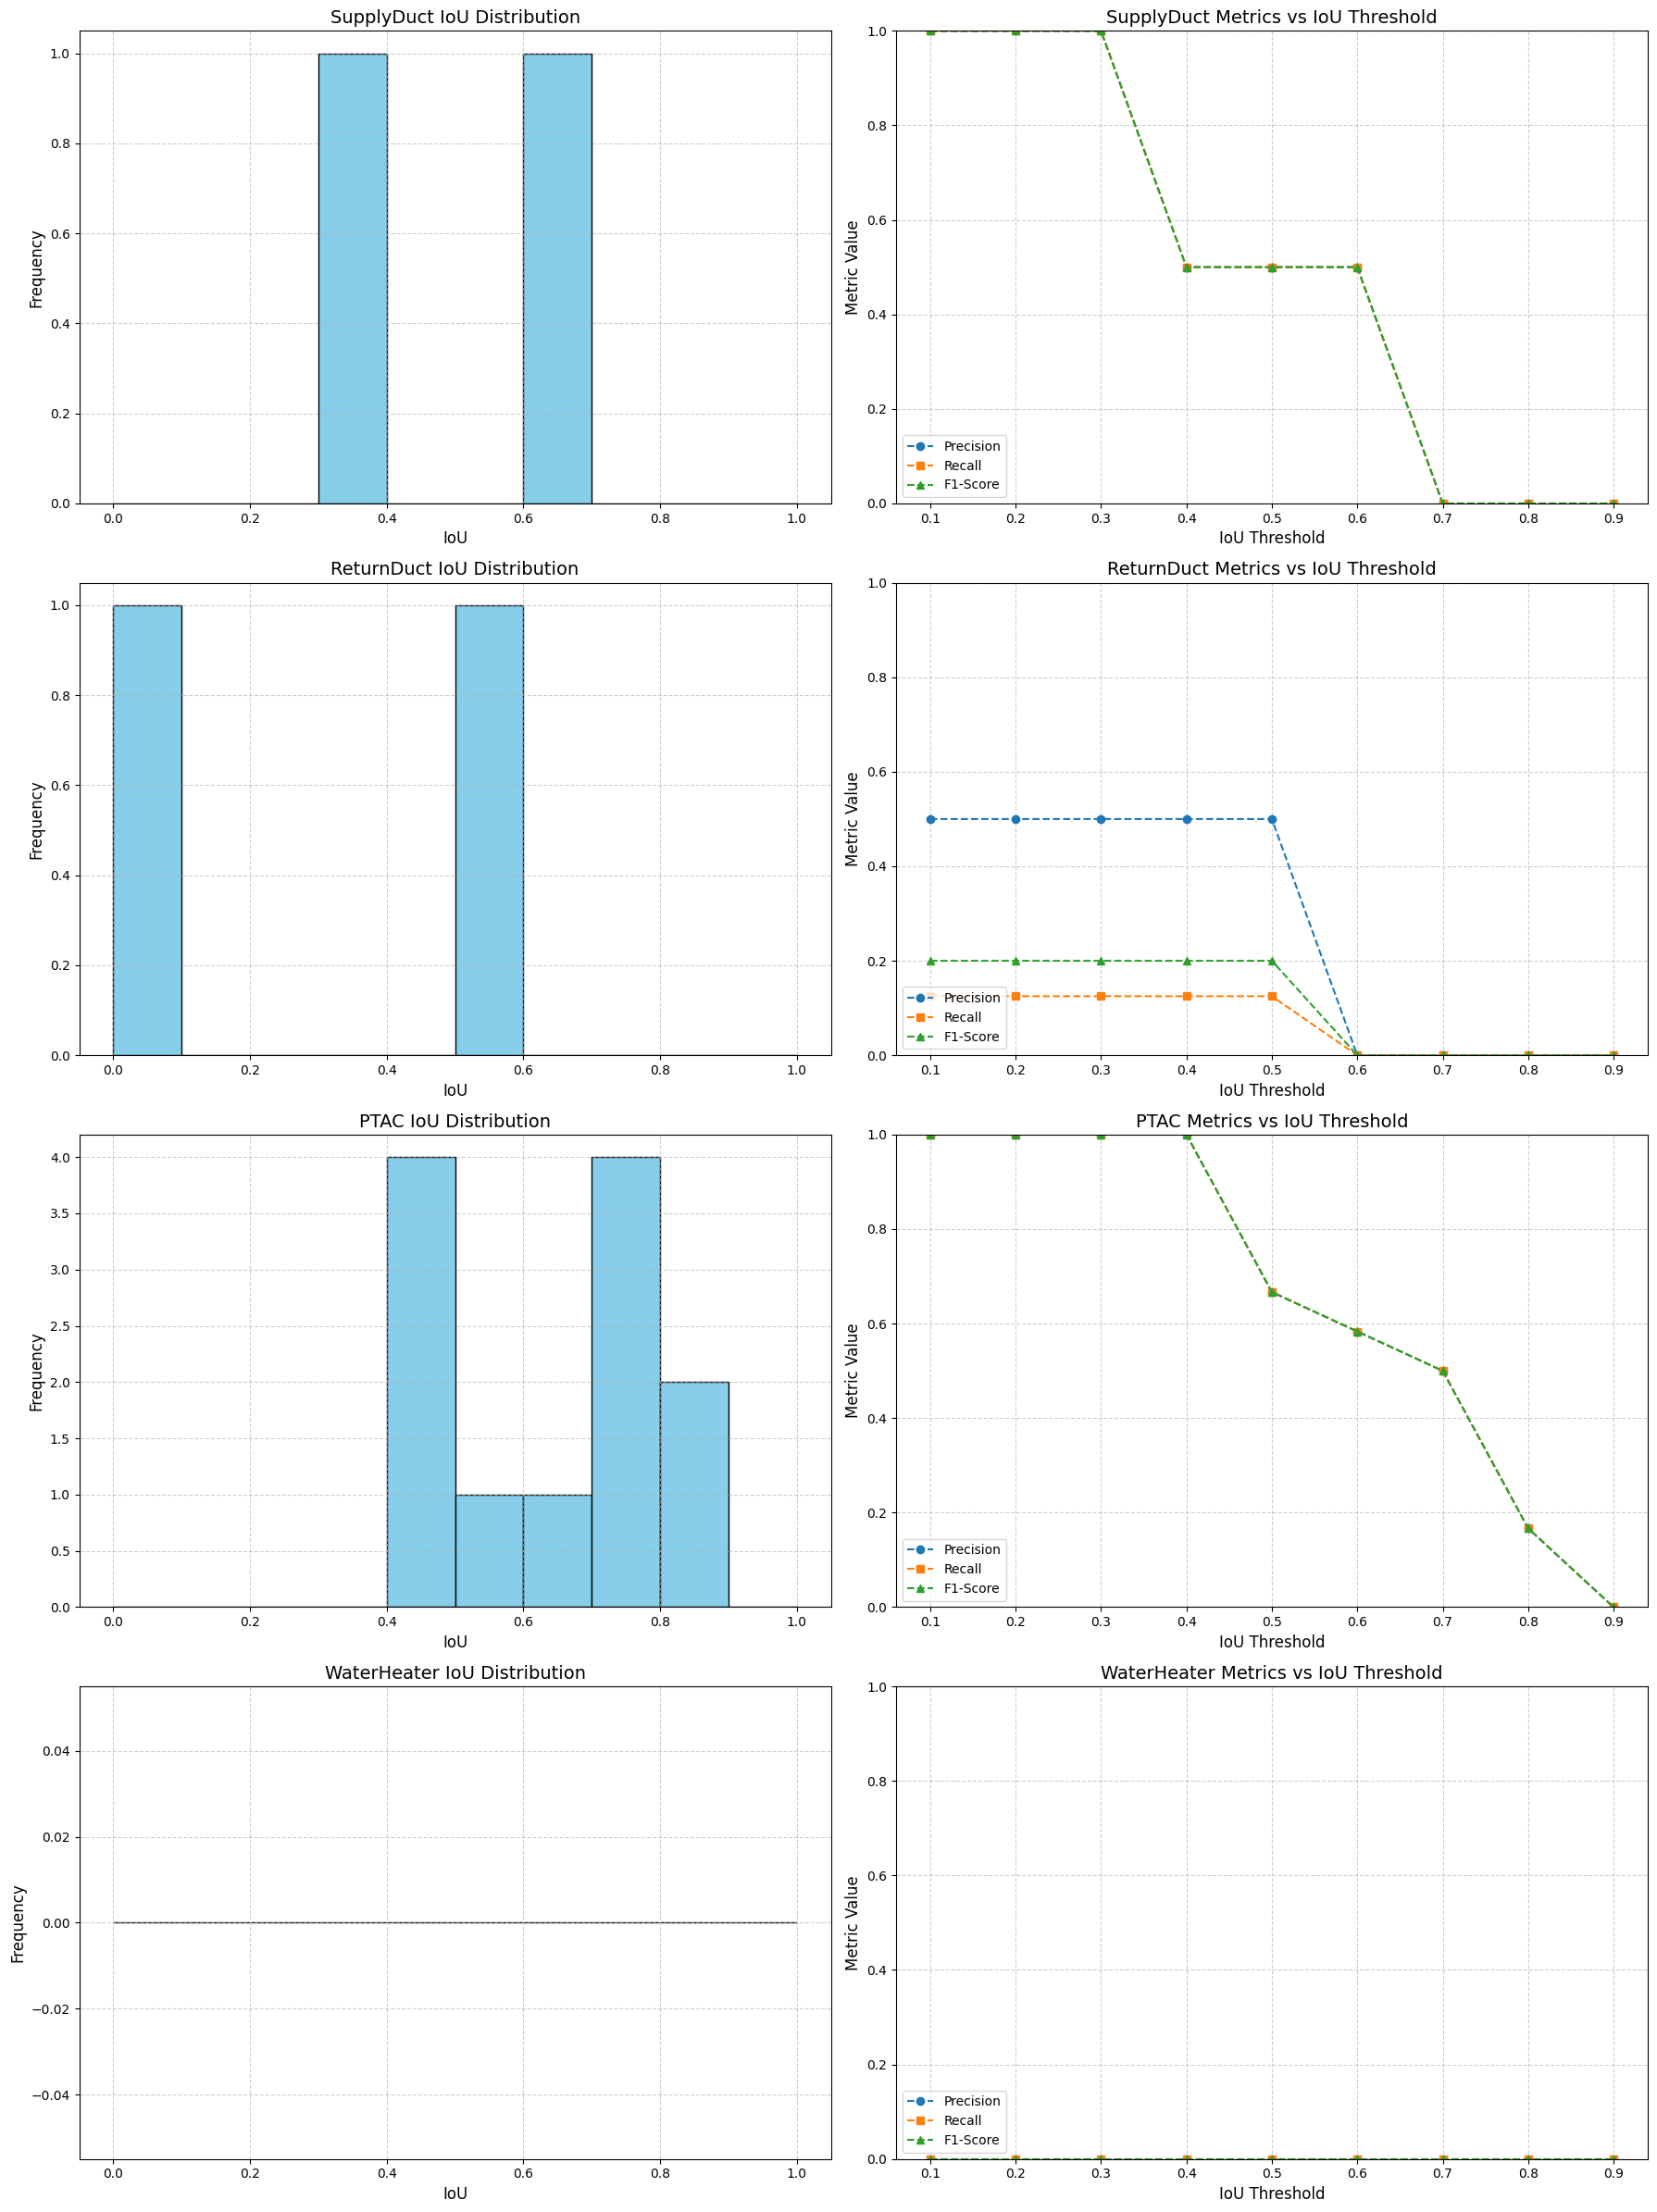

In [107]:
# Template names and IoU thresholds for analysis
template_names = ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater"]
iou_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Plot metrics for each template type
plot_template_metrics(predicted_boxes, ground_truth_boxes, template_names, iou_thresholds)


The IoU distribution plots show how well the predicted bounding boxes align with the ground truth for each template type:
- For SupplyDuct, predictions align well with a strong peak around IoU ~0.8, indicating good overlap.
- ReturnDuct has no meaningful IoU values, reflecting a complete failure in generating accurate predictions.
- For PTAC, the IoU values are distributed more broadly, with most predictions falling between 0.2 and 0.6, showing some moderate alignment but also significant inconsistency in precision.

The Performance Metrics vs. IoU Threshold plots evaluate precision, recall, and F1-Score at varying IoU thresholds.
- SupplyDuct maintains good metrics at lower thresholds (0.1–0.5) but drops significantly at stricter thresholds due to less precise alignment.
- ReturnDuct consistently scores near zero across all thresholds, further confirming poor prediction performance.
- PTAC shows moderate performance at lower thresholds, but all metrics decline sharply as thresholds increase, highlighting its struggle with precise localization.


These results suggest strong detection for SupplyDuct, limited success for PTAC, and a need for significant improvement in ReturnDuct predictions.